# Cesar's Sentiment Strategy — Simple Version

**One-liner:** Read AAII (retail) + NAAIM (pro managers) sentiment every Friday → XGBoost classifier predicts which of {ACWI, AGG, GLD, BSV} wins next week → probabilities become portfolio weights (5% floor, ≤25pp turnover/week).

**Universe:** ACWI (global equity) / AGG (bonds) / GLD (gold) / BSV (short-term Treasuries). Long-only, sum = 100%.

**Train / test split**
- **Train:** through 2024-12-31. Walk-forward CV (annual refit, expanding window 2010 → 2024) gives honest OOS training metrics.
- **Test (out-of-sample):** 2025-01-01 → today. One model fit on all of train, then frozen.

**Hyperparameters are tuned by walk-forward CV on the training set only** (§6b) — 2025 never enters the search, per `CLAUDE.md §10.2`.


## 1) Imports & config

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pickle
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

np.random.seed(42)
sns.set_style('whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)

_nb_dir = Path.cwd()
_vert = _nb_dir.parent if _nb_dir.name == "notebooks" else _nb_dir
_repo = _vert.parent

DATA    = _repo / "data"
RESULTS = _vert / "results";     RESULTS.mkdir(exist_ok=True)
SUBS    = _vert / "submissions"; SUBS.mkdir(exist_ok=True)

ETFS         = ['ACWI', 'AGG', 'GLD', 'BSV']
CLASS_OF     = {t: i for i, t in enumerate(ETFS)}    # ACWI=0, AGG=1, GLD=2, BSV=3
TRAIN_END    = pd.Timestamp('2024-12-31')
VAL_END      = pd.Timestamp('2025-12-31')   # scope test window to calendar 2025
TURNOVER_CAP = 0.25    # 25pp weekly L1 cap (project rule, NOT tuned)
COST_BPS     = 5       # 5 bps per unit of L1 turnover

print('Universe:', ETFS, '| Train end:', TRAIN_END.date())


Universe: ['ACWI', 'AGG', 'GLD', 'BSV'] | Train end: 2024-12-31


## Canonical blocks (inlined from shared/canonical.py)

These four blocks are inlined verbatim from `shared/canonical.py`. They define the shared KPI / turnover / submission schema all four verticals report against. Do not edit in place; edit `shared/canonical.py` and re-sync.

In [2]:
# === BEGIN canonical:constants ===
UNIVERSE = ["ACWI", "AGG", "GLD", "BSV"]
TEAM_ID = "TeamXX"
TRAIN_END = pd.Timestamp("2024-12-31")
VAL_END = pd.Timestamp("2025-12-31")
TURNOVER_CAP = 0.25
PERIODS_PER_YEAR = 52
RISK_FREE_RATE = 0.0
MAR = 0.0
MIN_PERIODS_FOR_RATIO = 24
RNG_SEED = 42

np.random.seed(RNG_SEED)
pd.set_option("display.float_format", "{:.4f}".format)
# === END canonical:constants ===

In [3]:
# === BEGIN canonical:kpis ===
def compute_kpis(
    returns: pd.Series,
    benchmark: pd.Series | None = None,
    *,
    periods_per_year: int = PERIODS_PER_YEAR,
    risk_free_rate: float = RISK_FREE_RATE,
    mar: float = MAR,
    min_periods_for_ratio: int = MIN_PERIODS_FOR_RATIO,
) -> dict:
    """Weekly KPI bank shared by every vertical.

    Sharpe uses mean excess return over sample-std (ddof=1), annualised by
    sqrt(periods_per_year). Sortino uses the textbook downside deviation:
    sqrt(mean(min(excess - mar_per_period, 0)^2)). Returns NaN for the
    ratio metrics when the sample is shorter than min_periods_for_ratio.
    """
    r = returns.dropna()
    if r.empty:
        return {}
    rf_per = risk_free_rate / periods_per_year
    mar_per = mar / periods_per_year
    ann = float(np.sqrt(periods_per_year))

    excess = r - rf_per
    mean_excess = float(excess.mean())
    vol = float(excess.std(ddof=1))

    downside = np.minimum(excess - mar_per, 0.0)
    downside_dev = float(np.sqrt(np.mean(np.square(downside))))

    equity = (1.0 + r).cumprod()
    drawdown = equity / equity.cummax() - 1.0
    n = len(r)
    n_years = n / periods_per_year
    total_return = float(equity.iloc[-1] - 1.0)
    cagr = float(equity.iloc[-1] ** (1.0 / n_years) - 1.0) if n_years > 0 else float("nan")
    max_dd = float(drawdown.min())

    enough = n >= min_periods_for_ratio
    sharpe = (mean_excess / vol) * ann if enough and vol > 0 else float("nan")
    sortino = (mean_excess / downside_dev) * ann if enough and downside_dev > 0 else float("nan")
    calmar = cagr / abs(max_dd) if max_dd < 0 and not np.isnan(cagr) else float("nan")

    out = {
        "n_periods": int(n),
        "total_return": total_return,
        "CAGR": cagr,
        "ann_return": float(r.mean() * periods_per_year),
        "ann_vol": float(r.std(ddof=1) * ann),
        "Sharpe": float(sharpe),
        "Sortino": float(sortino),
        "max_drawdown": max_dd,
        "calmar": float(calmar),
        "hit_rate": float((r > 0).mean()),
        "best_period": float(r.max()),
        "worst_period": float(r.min()),
    }
    if benchmark is not None:
        bench = benchmark.reindex(r.index).dropna()
        active = (r - bench).dropna()
        if len(active) >= min_periods_for_ratio and active.std(ddof=1) > 0:
            out["active_sharpe_vs_bench"] = float(
                (active.mean() / active.std(ddof=1)) * ann
            )
        else:
            out["active_sharpe_vs_bench"] = float("nan")
        out["excess_ann_return"] = (
            float(active.mean() * periods_per_year) if not active.empty else float("nan")
        )
    return out
# === END canonical:kpis ===

In [4]:
# === BEGIN canonical:turnover ===
def project_to_turnover_ball(
    target: pd.Series,
    previous: pd.Series,
    *,
    cap: float = TURNOVER_CAP,
) -> pd.Series:
    """L1-ball projection of target toward previous so sum(|target-previous|) <= cap.

    Returns a Series indexed by UNIVERSE, clipped to [0,1] and renormalised to
    sum to 1. Matches the math each vertical already used independently.
    """
    target = target.reindex(UNIVERSE).astype(float)
    previous = previous.reindex(UNIVERSE).astype(float)
    delta = target - previous
    total = float(np.abs(delta).sum())
    if total <= cap + 1e-12:
        out = target.copy()
    else:
        out = previous + delta * (cap / total)
    out = out.clip(lower=0.0, upper=1.0)
    s = float(out.sum())
    return out / s if s > 0 else target
# === END canonical:turnover ===

In [5]:
# === BEGIN canonical:submission ===
def write_submission_csv(
    weights_fraction: pd.Series,
    week: "pd.Timestamp | str",
    team_id: str,
    out_dir: Path,
    *,
    vertical_tag: str | None = None,
    previous_path: Path | None = None,
    enforce_turnover: bool = True,
) -> Path:
    """Write the weekly submission CSV in the format mandated by CLAUDE.md.

    Input weights are fractions in [0,1] summing to 1. They are scaled to
    percentages, rounded to two decimals, and the residual is added to the
    largest weight so the row sums to exactly 100.00. Per-vertical draft files
    get a {team_id}_{vertical_tag}_{date}.csv name; the final team submission
    uses {team_id}_{date}.csv. Header is week,team_id,acwi,agg,gld,bsv.
    """
    week_ts = pd.Timestamp(week)
    week_str = week_ts.strftime("%Y-%m-%d")
    w = weights_fraction.reindex(UNIVERSE).astype(float) * 100.0
    w = w.round(2)
    residual = round(100.0 - float(w.sum()), 2)
    largest = w.idxmax()
    w.loc[largest] = round(float(w.loc[largest]) + residual, 2)
    if not ((w >= 0).all() and (w <= 100).all()):
        raise ValueError(f"weights out of [0,100]: {w.to_dict()}")
    if abs(float(w.sum()) - 100.0) > 1e-6:
        raise ValueError(f"weights do not sum to 100: {float(w.sum())}")
    if enforce_turnover and previous_path is not None and Path(previous_path).exists():
        prev_df = pd.read_csv(previous_path)
        prev_w = pd.Series(
            {k: float(prev_df.iloc[0][k.lower()]) for k in UNIVERSE},
        ).reindex(UNIVERSE)
        turnover_pp = float((w - prev_w).abs().sum())
        if turnover_pp - 25.0 > 1e-9:
            raise ValueError(
                f"turnover {turnover_pp:.2f}pp > 25.00pp vs {Path(previous_path).name}"
            )
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    name = (
        f"{team_id}_{vertical_tag}_{week_str}.csv"
        if vertical_tag
        else f"{team_id}_{week_str}.csv"
    )
    path = out_dir / name
    row = {
        "week": week_str,
        "team_id": team_id,
        "acwi": w["ACWI"],
        "agg": w["AGG"],
        "gld": w["GLD"],
        "bsv": w["BSV"],
    }
    pd.DataFrame([row], columns=["week", "team_id", "acwi", "agg", "gld", "bsv"]).to_csv(
        path, index=False, float_format="%.2f",
    )
    return path
# === END canonical:submission ===

In [6]:
# ETFS is Cesar-local alias for UNIVERSE. CLASS_OF maps to integer class index.
assert ETFS == UNIVERSE, f"ETFS {ETFS} must equal UNIVERSE {UNIVERSE}"
print("Canonical constants loaded. ETFS == UNIVERSE:", ETFS == UNIVERSE)


Canonical constants loaded. ETFS == UNIVERSE: True


## 2) Load & align data

ETF prices, AAII bull/bear survey, NAAIM exposure index — all align onto the Friday-close calendar via forward-fill (publications land Wed/Thu, so by Friday close they're public).

In [7]:
# Keep all dates (including early 2008 where ACWI was still pre-launch / NaN).
# We need them so the Friday calendar reaches back as far as the other ETFs
# trade — ACWI gets back-filled to NaN and naturally drops out of the labels.
etfs  = pd.read_csv(DATA / 'etfs_daily.csv',   index_col=0, parse_dates=True)[ETFS]
aaii  = pd.read_csv(DATA / 'aaii_weekly.csv',  index_col=0, parse_dates=True)
naaim = pd.read_csv(DATA / 'naaim_weekly.csv', index_col=0, parse_dates=True)

fridays = etfs.index[etfs.index.weekday == 4]

def to_friday_ffill(df):
    return (df.reindex(df.index.union(fridays))
              .sort_index().ffill()
              .reindex(fridays))

etf_w   = etfs.reindex(fridays).ffill()
aaii_w  = to_friday_ffill(aaii)
naaim_w = to_friday_ffill(naaim)

print(f'Friday calendar: {len(fridays)} weeks  |  '
      f'{fridays.min().date()} → {fridays.max().date()}')


Friday calendar: 979 weeks  |  2007-01-05 → 2026-05-29


## 3) Features

Stationary, leak-free, weekly. Row at t uses only data known by Friday close of week t.

In [8]:
def build_features(aaii_df, naaim_df):
    f = pd.DataFrame(index=aaii_df.index)

    # AAII (retail) — bull/bear spread, z-score, percentile rank, momentum, neutral %.
    bbs = aaii_df['bullish'] - aaii_df['bearish']
    f['aaii_bull_bear_spread'] = bbs
    f['aaii_bbs_z_52w']        = ((bbs - bbs.rolling(52).mean()) / bbs.rolling(52).std().replace(0, float('nan'))).fillna(0)
    f['aaii_bbs_pct_52w']      = bbs.rolling(52).rank(pct=True)
    f['aaii_bull_5w_delta']    = aaii_df['bullish'] - aaii_df['bullish'].shift(5)
    f['aaii_neutral_pct']      = aaii_df['neutral']

    # NAAIM (active managers) — mean exposure, z-score, momentum, IQR dispersion.
    m = naaim_df['naaim_mean']
    f['naaim_mean']       = m
    f['naaim_z_26w']      = ((m - m.rolling(26).mean()) / m.rolling(26).std().replace(0, float('nan'))).fillna(0)
    f['naaim_delta_4w']   = m - m.shift(4)
    f['naaim_dispersion'] = naaim_df['naaim_q3'] - naaim_df['naaim_q1']

    return f.dropna()

feats = build_features(aaii_w, naaim_w)
print('Features:', feats.shape, '|', feats.index.min().date(), '→', feats.index.max().date())
feats.tail(3)


Features: (928, 9) | 2008-01-04 → 2026-05-29


,aaii_bull_bear_spread,aaii_bbs_z_52w,aaii_bbs_pct_52w,aaii_bull_5w_delta,aaii_neutral_pct,naaim_mean,naaim_z_26w,naaim_delta_4w,naaim_dispersion
Date,,,,,,,,,
2026-05-15,0.2127,0.0000,0.5096,0.0000,0.2861,77.3400,-0.7656,-2.1500,21.2500
2026-05-22,0.2127,0.0000,0.5096,0.0000,0.2861,82.0200,-0.3251,-12.1300,31.0000
2026-05-29,0.2127,0.0000,0.5096,0.0000,0.2861,98.3900,1.0738,4.6000,12.5000


## 4) Labels — next-week winning ETF

`y_t = argmax_i return_{t→t+1}`. Features at week t, labels indexed at week t (representing the *next* week's winner).

In [9]:
rets   = etf_w.pct_change().shift(-1)            # return t→t+1, stamped at t
labels = (rets.dropna().idxmax(axis=1).map(CLASS_OF)
              .rename('y'))                       # integer-encoded winning ETF

common  = feats.index.intersection(labels.index)
X_all   = feats.loc[common]
y_all   = labels.loc[common].astype(int)
mask_tr = X_all.index <= TRAIN_END
mask_te = (X_all.index > TRAIN_END) & (X_all.index <= VAL_END)

print(f'Training rows: {mask_tr.sum()}   Validation rows: {mask_te.sum()}')
print('\nLabel distribution (train):')
print(y_all[mask_tr].map({i: t for t, i in CLASS_OF.items()})
      .value_counts(normalize=True).round(3))


Training rows: 846   Validation rows: 50

Label distribution (train):
y
ACWI   0.4050
GLD    0.3400
AGG    0.1610
BSV    0.0930
Name: proportion, dtype: float64


## 5) Weight pipeline

Probabilities → constrained percentage weights. Per week:
1. Floor each ETF (`max(p, floor)`), renormalize.
2. Project onto the L1 turnover ball — if `|w − w_prev|₁ > 25pp`, scale the delta back inside the cap. 5bp of headroom for rounding.
3. Round to 2-decimal percentages; assign the residual to the largest position so the row sums to exactly 100.

The `floor` parameter is tuned by walk-forward CV in §6b; everything downstream reads `FLOOR_TUNED`.

In [10]:
def project_to_turnover_ball(w_target, w_prev, max_l1=TURNOVER_CAP):
    delta = w_target - w_prev
    l1 = float(np.abs(delta).sum())
    if l1 <= max_l1 + 1e-12:
        return w_target.copy()
    return w_prev + delta * (max_l1 / l1)

def round_to_pct(w):
    pct = np.round(np.asarray(w, dtype=float) * 100, 2)
    residual = round(100.0 - pct.sum(), 2)
    j = int(np.argmax(pct))
    pct[j] = round(pct[j] + residual, 2)
    return pct

def predict_weights(probs, w_prev, floor=0.05, max_turnover=TURNOVER_CAP):
    w_prev = np.asarray(w_prev, dtype=float)
    if w_prev.sum() > 1.5:           # accept either percentages or fractions
        w_prev = w_prev / 100.0
    w = np.maximum(probs, floor); w = w / w.sum()
    w = project_to_turnover_ball(w, w_prev, max_turnover - 0.0005)
    w = np.clip(w, 0, 1); w = w / w.sum()
    return round_to_pct(w)


## 6) Model + walk-forward training

Parameterized XGBoost factory + walk-forward CV helper. The walk-forward fits one model per year (expanding window) and produces honest OOS predictions over the entire training window.

In [11]:
def xgb_factory(max_depth=3, n_estimators=200, learning_rate=0.05):
    return xgb.XGBClassifier(
        objective='multi:softprob',
        max_depth=max_depth, n_estimators=n_estimators,
        learning_rate=learning_rate,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
        tree_method='exact',     # deterministic across runs
        n_jobs=1, random_state=42, eval_metric='mlogloss', num_class=4,
    )

def walk_forward(X, y, etf_returns, model_factory=None, weight_pipeline=None,
                 first_year=2010, last_year=2024):
    """Expanding-window walk-forward. Returns weekly OOS portfolio returns + weights."""
    if model_factory is None:
        model_factory = xgb_factory
    if weight_pipeline is None:
        weight_pipeline = lambda p, wp: predict_weights(p, wp)
    all_weights, all_rets = [], []
    for yr in range(first_year, last_year + 1):
        tr = X.index.year <  yr
        te = X.index.year == yr
        if not tr.any() or not te.any():
            continue
        if len(set(y[tr].unique())) < 4:  # skip folds missing a class
            continue
        m = model_factory().fit(X[tr], y[tr])
        probs = m.predict_proba(X[te])
        w_prev = np.full(4, 0.25)
        ws = np.zeros((te.sum(), 4))
        for i, p in enumerate(probs):
            pct = weight_pipeline(p, w_prev)
            ws[i] = pct / 100.0
            w_prev = pct / 100.0
        w_df = pd.DataFrame(ws, index=X[te].index, columns=ETFS)
        r_df = etf_returns.reindex(w_df.index)
        all_weights.append(w_df)
        all_rets.append((w_df.values * r_df.values).sum(axis=1))

    weights = pd.concat(all_weights)
    returns = pd.Series(np.concatenate(all_rets), index=weights.index)
    return returns, weights


### 6b) Hyperparameter sweep via walk-forward CV

Grid search on training years only — **2025 data never enters the search** (per `CLAUDE.md §10.2`). Primary metric is net-of-cost walk-forward Sharpe; ties break by CAGR. `floor` is included per `§10.8`.

Whatever config wins is what the final model uses for 2025, YTD, and live submissions — no peeking, no cherry-picking. Runtime: ~2-3 minutes (27 configs × 15 folds = 405 XGBoost fits).

In [12]:
GRID = list(product(
    [2, 3, 4],          # max_depth
    [200],              # n_estimators (200 is a stable mid-point)
    [0.03, 0.05, 0.1],  # learning_rate
    [0.0, 0.05, 0.10],  # floor (per CLAUDE.md §10.8)
))  # 3 × 1 × 3 × 3 = 27 combos

print(f'Sweeping {len(GRID)} configurations × 15 walk-forward folds...')

records = []
for max_depth, n_est, lr, floor in GRID:
    factory = (lambda md=max_depth, ne=n_est, l=lr:
        xgb_factory(max_depth=md, n_estimators=ne, learning_rate=l))
    wpipe = (lambda p, wp, fl=floor:
        predict_weights(p, wp, floor=fl, max_turnover=TURNOVER_CAP))
    rets_wf, w_wf = walk_forward(
        X_all[mask_tr], y_all[mask_tr], rets,
        model_factory=factory, weight_pipeline=wpipe,
    )
    cost = w_wf.diff().abs().sum(axis=1) * (COST_BPS / 10000.0)
    net  = rets_wf - cost.reindex(rets_wf.index).fillna(0)
    ann  = 52
    mu, sig = net.mean() * ann, net.std() * np.sqrt(ann)
    sh   = mu / sig if sig > 0 else np.nan
    cagr = (1 + net).cumprod().iloc[-1] ** (ann / len(net)) - 1
    records.append({
        'max_depth':     max_depth,
        'n_estimators':  n_est,
        'learning_rate': lr,
        'floor':         floor,
        'sharpe_net':    sh,
        'cagr_net':      cagr,
    })

sweep = (pd.DataFrame(records)
          .sort_values(['sharpe_net', 'cagr_net'], ascending=False)
          .reset_index(drop=True))
sweep.to_csv(RESULTS / 'sweep_results.csv', index=False)
print('✓ Wrote results/sweep_results.csv')

BEST = sweep.iloc[0].to_dict()
print('\nBest config (walk-forward training only):')
print(f"  max_depth     = {int(BEST['max_depth'])}")
print(f"  n_estimators  = {int(BEST['n_estimators'])}")
print(f"  learning_rate = {BEST['learning_rate']}")
print(f"  floor         = {BEST['floor']}")
print(f"  → Sharpe (net) = {BEST['sharpe_net']:.3f}   CAGR (net) = {BEST['cagr_net']:.1%}")

MAX_DEPTH_TUNED = int(BEST['max_depth'])
N_EST_TUNED     = int(BEST['n_estimators'])
LR_TUNED        = float(BEST['learning_rate'])
FLOOR_TUNED     = float(BEST['floor'])

sweep.head(10)


Sweeping 27 configurations × 15 walk-forward folds...


✓ Wrote results/sweep_results.csv

Best config (walk-forward training only):
  max_depth     = 2
  n_estimators  = 200
  learning_rate = 0.03
  floor         = 0.1
  → Sharpe (net) = 0.699   CAGR (net) = 6.5%


,max_depth,n_estimators,learning_rate,floor,sharpe_net,cagr_net
0,2,200,0.0300,0.1000,0.6992,0.0651
1,2,200,0.0300,0.0500,0.6930,0.0663
2,2,200,0.0300,0.0000,0.6927,0.0665
3,2,200,0.0500,0.1000,0.6920,0.0647
4,2,200,0.0500,0.0500,0.6778,0.0654
5,3,200,0.0500,0.1000,0.6773,0.0643
6,4,200,0.0300,0.1000,0.6771,0.0640
7,3,200,0.1000,0.1000,0.6749,0.0648
8,2,200,0.0500,0.0000,0.6748,0.0656
9,3,200,0.0300,0.1000,0.6730,0.0630


### 6c) Run walk-forward CV with the tuned config

Same expanding-window walk-forward, now using the winning hyperparameters. Produces the canonical `oos_rets` and `oos_w` used by every downstream section.

In [13]:
tuned_factory = lambda: xgb_factory(
    max_depth=MAX_DEPTH_TUNED,
    n_estimators=N_EST_TUNED,
    learning_rate=LR_TUNED,
)
tuned_pipe = lambda p, wp: predict_weights(
    p, wp, floor=FLOOR_TUNED, max_turnover=TURNOVER_CAP)

oos_rets, oos_w = walk_forward(
    X_all[mask_tr], y_all[mask_tr], rets,
    model_factory=tuned_factory, weight_pipeline=tuned_pipe,
)
print(f'Walk-forward OOS (tuned): {len(oos_rets)} weeks, '
      f'{oos_rets.index.min().date()} → {oos_rets.index.max().date()}')


Walk-forward OOS (tuned): 758 weeks, 2010-01-08 → 2024-12-27


## 7) Training metrics (walk-forward OOS, tuned)

In [14]:
def perf_metrics(returns, name):
    """Cesar's display schema, computed via canonical compute_kpis (weekly, RF=0)."""
    can = compute_kpis(returns)
    if not can:
        return pd.Series(
            {"CAGR": np.nan, "Sharpe": np.nan, "Sortino": np.nan,
             "Max DD": np.nan, "Calmar": np.nan, "Hit rate": np.nan},
            name=name,
        )
    return pd.Series(
        {
            "CAGR": can.get("CAGR", np.nan),
            "Sharpe": can.get("Sharpe", np.nan),
            "Sortino": can.get("Sortino", np.nan),
            "Max DD": can.get("max_drawdown", np.nan),
            "Calmar": can.get("calmar", np.nan),
            "Hit rate": can.get("hit_rate", np.nan),
        },
        name=name,
    )

def turnover(weights_df):
    return weights_df.diff().abs().sum(axis=1).mean()

idx_tr = oos_rets.index
metrics_train = pd.concat([
    perf_metrics(oos_rets,                                                                "XGBoost"),
    perf_metrics(rets[ETFS].mul([0.25]*4).sum(axis=1).reindex(idx_tr),                    "EW 25x4"),
    perf_metrics(rets[["ACWI","AGG"]].mul([0.6, 0.4]).sum(axis=1).reindex(idx_tr),        "60/40"),
    perf_metrics(rets["ACWI"].reindex(idx_tr),                                            "ACWI BH"),
], axis=1).T
metrics_train["Turnover/wk (pp)"] = [turnover(oos_w) * 100, np.nan, np.nan, np.nan]
metrics_train.to_csv(RESULTS / "metrics_training.csv")
print("Wrote results/metrics_training.csv")
metrics_train.round(3)


Wrote results/metrics_training.csv


,CAGR,Sharpe,Sortino,Max DD,Calmar,Hit rate,Turnover/wk (pp)
XGBoost,0.0700,0.7510,1.1290,-0.1800,0.3910,0.5470,19.2980
EW 25x4,0.0520,0.7600,1.1500,-0.1520,0.3400,0.5530,NaN
60/40,0.0690,0.6840,1.0010,-0.2200,0.3130,0.5790,NaN
ACWI BH,0.0940,0.6190,0.8940,-0.3210,0.2930,0.5740,NaN


## 8) Out-of-sample 2025

Fit one final XGBoost with the **tuned hyperparameters** on all training data (≤2024-12-31), freeze it, and generate 2025 weights with the locked weight pipeline. Starting `w_prev` for the first 2025 week is the last walk-forward weight.

In [15]:
final_model = xgb_factory(
    max_depth=MAX_DEPTH_TUNED,
    n_estimators=N_EST_TUNED,
    learning_rate=LR_TUNED,
).fit(X_all[mask_tr], y_all[mask_tr])
with open(RESULTS / 'final_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)
print('✓ Wrote results/final_model.pkl (tuned)')

probs_2025 = final_model.predict_proba(X_all[mask_te])
weights_2025 = []
w_prev = oos_w.iloc[-1].values
for p in probs_2025:
    pct = predict_weights(p, w_prev, floor=FLOOR_TUNED, max_turnover=TURNOVER_CAP)
    weights_2025.append(pct)
    w_prev = pct / 100.0
weights_2025 = pd.DataFrame(weights_2025, index=X_all[mask_te].index, columns=ETFS)

rets_2025 = (weights_2025 / 100.0 * rets.reindex(weights_2025.index)).sum(axis=1)
weights_2025.to_csv(RESULTS / 'weights_2025.csv')
print('✓ Wrote results/weights_2025.csv')

idx_25 = weights_2025.index
m25 = pd.concat([
    perf_metrics(rets_2025,                                                                  'XGBoost 2025'),
    perf_metrics(rets.reindex(idx_25).mul([0.25]*4).sum(axis=1),                             'EW 25x4'),
    perf_metrics(rets.reindex(idx_25)[['ACWI','AGG']].mul([0.6, 0.4]).sum(axis=1),           '60/40'),
    perf_metrics(rets.reindex(idx_25)['ACWI'],                                               'ACWI BH'),
], axis=1).T
m25.to_csv(RESULTS / 'metrics_2025.csv')
print('✓ Wrote results/metrics_2025.csv')
m25.round(3)


✓ Wrote results/final_model.pkl (tuned)
✓ Wrote results/weights_2025.csv
✓ Wrote results/metrics_2025.csv


,CAGR,Sharpe,Sortino,Max DD,Calmar,Hit rate
XGBoost 2025,0.3070,2.8660,4.9620,-0.0480,6.3650,0.7000
EW 25x4,0.2460,3.7170,7.8140,-0.0220,11.3470,0.7400
60/40,0.1710,1.7000,2.6600,-0.0780,2.2000,0.6000
ACWI BH,0.2320,1.3720,2.0340,-0.1430,1.6300,0.6000


## 9) Year-to-date 2026

Same locked (tuned) model, same weight pipeline, but applied to 2026 features. The first `w_prev` continues from the last 2025 weight.

In [16]:
mask_ytd = X_all.index > VAL_END

if mask_ytd.any():
    probs_ytd = final_model.predict_proba(X_all[mask_ytd])
    rows_ytd = []
    w_prev = weights_2025.iloc[-1].values / 100.0
    for p in probs_ytd:
        pct = predict_weights(p, w_prev, floor=FLOOR_TUNED, max_turnover=TURNOVER_CAP)
        rows_ytd.append(pct)
        w_prev = pct / 100.0
    weights_ytd = pd.DataFrame(rows_ytd, index=X_all[mask_ytd].index, columns=ETFS)
    rets_ytd    = (weights_ytd / 100.0 * rets.reindex(weights_ytd.index)).sum(axis=1)
    weights_ytd.to_csv(RESULTS / 'weights_ytd.csv')

    idx_ytd = weights_ytd.index
    m_ytd = pd.concat([
        perf_metrics(rets_ytd,                                                              'XGBoost YTD'),
        perf_metrics(rets.reindex(idx_ytd).mul([0.25]*4).sum(axis=1),                       'EW 25x4'),
        perf_metrics(rets.reindex(idx_ytd)[['ACWI','AGG']].mul([0.6, 0.4]).sum(axis=1),     '60/40'),
        perf_metrics(rets.reindex(idx_ytd)['ACWI'],                                         'ACWI BH'),
    ], axis=1).T
    m_ytd.to_csv(RESULTS / 'metrics_ytd.csv')
    print(f'YTD 2026: {len(weights_ytd)} weeks, '
          f'{idx_ytd.min().date()} → {idx_ytd.max().date()}')
    print('✓ Wrote results/weights_ytd.csv, results/metrics_ytd.csv')
    m_ytd.round(3)
else:
    weights_ytd = pd.DataFrame(columns=ETFS)
    rets_ytd    = pd.Series(dtype=float)
    m_ytd       = pd.DataFrame()
    print('No 2026 data yet — YTD section skipped.')


YTD 2026: 20 weeks, 2026-01-02 → 2026-05-22
✓ Wrote results/weights_ytd.csv, results/metrics_ytd.csv


## 10) Summary — performance across all periods

One table comparing **Cesar XGBoost** against three benchmarks (Equal-weight 25x4, 60/40 ACWI/AGG, ACWI buy-and-hold) over three windows:

- **Train** — walk-forward OOS, 2010 → 2024 (annual refit, expanding window)
- **Test 2025** — locked tuned model, 2025-01-03 → 2025-12-26
- **YTD 2026** — locked tuned model, 2026 to date

In [17]:
STRATS = ['Cesar XGBoost', 'EW 25x4', '60/40', 'ACWI BH']

def period_block(strat_rets, period_idx, period_label):
    idx = period_idx
    bench_ew   = rets[ETFS].mul([0.25]*4).sum(axis=1).reindex(idx)
    bench_6040 = rets[['ACWI','AGG']].mul([0.6, 0.4]).sum(axis=1).reindex(idx)
    bench_acwi = rets['ACWI'].reindex(idx)
    df = pd.concat([
        perf_metrics(strat_rets.reindex(idx).dropna(), 'Cesar XGBoost'),
        perf_metrics(bench_ew.dropna(),                'EW 25x4'),
        perf_metrics(bench_6040.dropna(),              '60/40'),
        perf_metrics(bench_acwi.dropna(),              'ACWI BH'),
    ], axis=1).T
    df.index.name = 'Strategy'
    return pd.concat({period_label: df}, names=['Period'])

blocks = [
    period_block(oos_rets,    oos_rets.index,    f'Train (walk-forward {idx_tr.min().year}-{idx_tr.max().year})'),
    period_block(rets_2025,   weights_2025.index, f'Test {idx_25.min().year}'),
]
if not weights_ytd.empty:
    blocks.append(period_block(rets_ytd, weights_ytd.index, f'YTD {weights_ytd.index.min().year}'))

summary = pd.concat(blocks)
summary.to_csv(RESULTS / 'metrics_summary.csv')
print('✓ Wrote results/metrics_summary.csv')

print(f"\nTuned hyperparameters (selected by walk-forward CV on TRAINING set only):")
print(f"  max_depth     = {MAX_DEPTH_TUNED}")
print(f"  n_estimators  = {N_EST_TUNED}")
print(f"  learning_rate = {LR_TUNED}")
print(f"  floor         = {FLOOR_TUNED}")

# Pretty-print: percentages for return/dd/hit, two decimals for ratios
disp = summary.copy()
for c in ['CAGR', 'Max DD', 'Hit rate']:
    disp[c] = disp[c].map(lambda x: f'{x:.1%}' if pd.notna(x) else '—')
for c in ['Sharpe', 'Sortino', 'Calmar']:
    disp[c] = disp[c].map(lambda x: f'{x:.2f}' if pd.notna(x) else '—')
disp


✓ Wrote results/metrics_summary.csv

Tuned hyperparameters (selected by walk-forward CV on TRAINING set only):
  max_depth     = 2
  n_estimators  = 200
  learning_rate = 0.03
  floor         = 0.1


CAGR Sharpe Sortino  Max DD  \
Period                         Strategy                                      
Train (walk-forward 2010-2024) Cesar XGBoost   7.0%   0.75    1.13  -18.0%   
                               EW 25x4         5.2%   0.76    1.15  -15.2%   
                               60/40           6.9%   0.68    1.00  -22.0%   
                               ACWI BH         9.4%   0.62    0.89  -32.1%   
Test 2025                      Cesar XGBoost  30.7%   2.87    4.96   -4.8%   
                               EW 25x4        24.6%   3.72    7.81   -2.2%   
                               60/40          17.1%   1.70    2.66   -7.8%   
                               ACWI BH        23.2%   1.37    2.03  -14.3%   
YTD 2026                       Cesar XGBoost  20.0%      —       —   -8.4%   
                               EW 25x4        12.3%      —       —   -6.7%   
                               60/40          19.3%      —       —   -6.3%   
                               ACWI BH        32.4%      —       —   -8.9%   

                                             Calmar Hit rate  
Period                         Strategy                       
Train (walk-forward 2010-2024) Cesar XGBoost   0.39    54.7%  
                               EW 25x4         0.34    55.3%  
                               60/40           0.31    57.9%  
                               ACWI BH         0.29    57.4%  
Test 2025                      Cesar XGBoost   6.37    70.0%  
                               EW 25x4        11.35    74.0%  
                               60/40           2.20    60.0%  
                               ACWI BH         1.63    60.0%  
YTD 2026                       Cesar XGBoost   2.39    60.0%  
                               EW 25x4         1.83    60.0%  
                               60/40           3.08    70.0%  
                               ACWI BH         3.66    60.0%

## 11) Figures

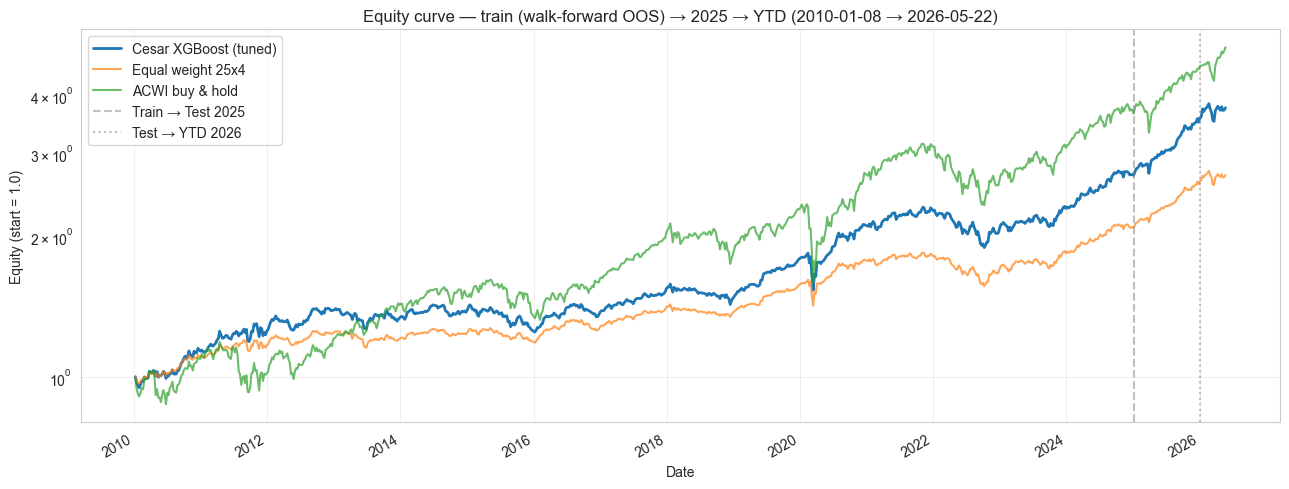

In [18]:
# 11.0) Combined equity curve across all three periods
parts_strat = [oos_rets, rets_2025]
parts_ew    = [
    rets[ETFS].mul([0.25]*4).sum(axis=1).reindex(oos_rets.index),
    rets[ETFS].mul([0.25]*4).sum(axis=1).reindex(weights_2025.index),
]
parts_acwi  = [
    rets['ACWI'].reindex(oos_rets.index),
    rets['ACWI'].reindex(weights_2025.index),
]
if not weights_ytd.empty:
    parts_strat.append(rets_ytd)
    parts_ew.append(rets[ETFS].mul([0.25]*4).sum(axis=1).reindex(weights_ytd.index))
    parts_acwi.append(rets['ACWI'].reindex(weights_ytd.index))

all_strat = pd.concat(parts_strat)
all_ew    = pd.concat(parts_ew)
all_acwi  = pd.concat(parts_acwi)

eq_strat = (1 + all_strat).cumprod()
eq_ew    = (1 + all_ew).cumprod()
eq_acwi  = (1 + all_acwi).cumprod()

fig, ax = plt.subplots(figsize=(13, 5))
eq_strat.plot(ax=ax, label='Cesar XGBoost (tuned)', lw=2)
eq_ew.plot(ax=ax,    label='Equal weight 25x4', alpha=0.7)
eq_acwi.plot(ax=ax,  label='ACWI buy & hold',   alpha=0.7)
ax.axvline(weights_2025.index.min(), color='grey', ls='--', alpha=0.5, label='Train → Test 2025')
if not weights_ytd.empty:
    ax.axvline(weights_ytd.index.min(), color='grey', ls=':',  alpha=0.5, label='Test → YTD 2026')
ax.set_title(f'Equity curve — train (walk-forward OOS) → 2025 → YTD ({eq_strat.index.min().date()} → {eq_strat.index.max().date()})')
ax.set_ylabel('Equity (start = 1.0)'); ax.set_yscale('log'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS / 'fig_combined_equity.png', dpi=120); plt.show()


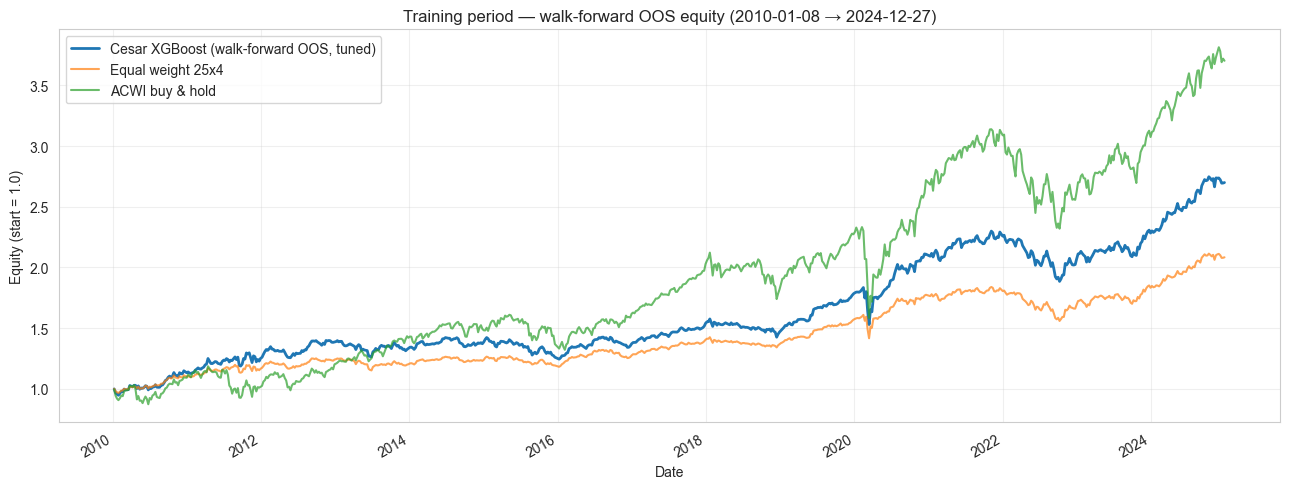

In [19]:
# 11.1) Training equity curve (walk-forward OOS, tuned)
oos_eq  = (1 + oos_rets).cumprod()
ew_eq   = (1 + rets[ETFS].mul([0.25]*4).sum(axis=1).reindex(idx_tr)).cumprod()
acwi_eq = (1 + rets['ACWI'].reindex(idx_tr)).cumprod()

fig, ax = plt.subplots(figsize=(13, 5))
oos_eq.plot(ax=ax,  label='Cesar XGBoost (walk-forward OOS, tuned)', lw=2)
ew_eq.plot(ax=ax,   label='Equal weight 25x4', alpha=0.7)
acwi_eq.plot(ax=ax, label='ACWI buy & hold',   alpha=0.7)
ax.set_title(f'Training period — walk-forward OOS equity ({idx_tr.min().date()} → {idx_tr.max().date()})')
ax.set_ylabel('Equity (start = 1.0)'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS / 'fig_7_1_training_equity.png', dpi=120); plt.show()


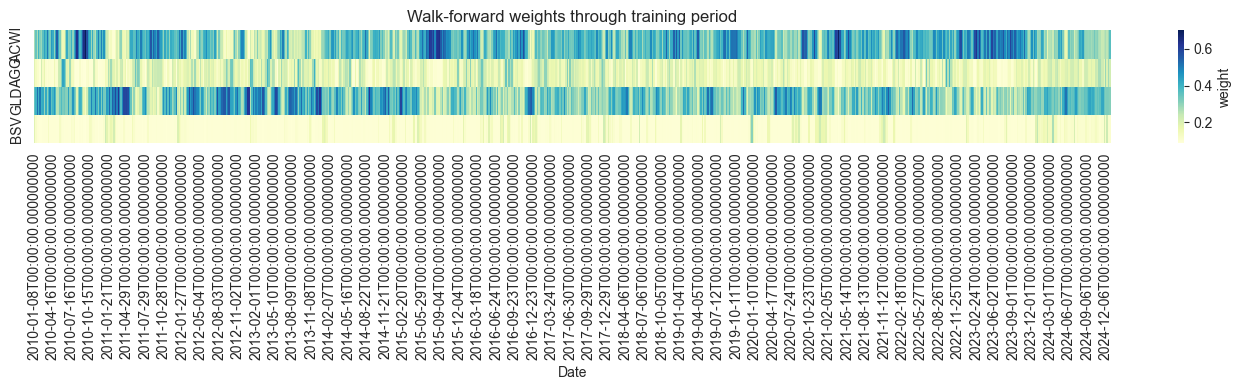

In [20]:
# 11.2) Weights heatmap (training walk-forward, tuned)
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(oos_w.T, cmap='YlGnBu', cbar_kws={'label': 'weight'}, ax=ax)
ax.set_title('Walk-forward weights through training period')
plt.tight_layout()
plt.savefig(RESULTS / 'fig_7_4_weights_heatmap.png', dpi=120); plt.show()


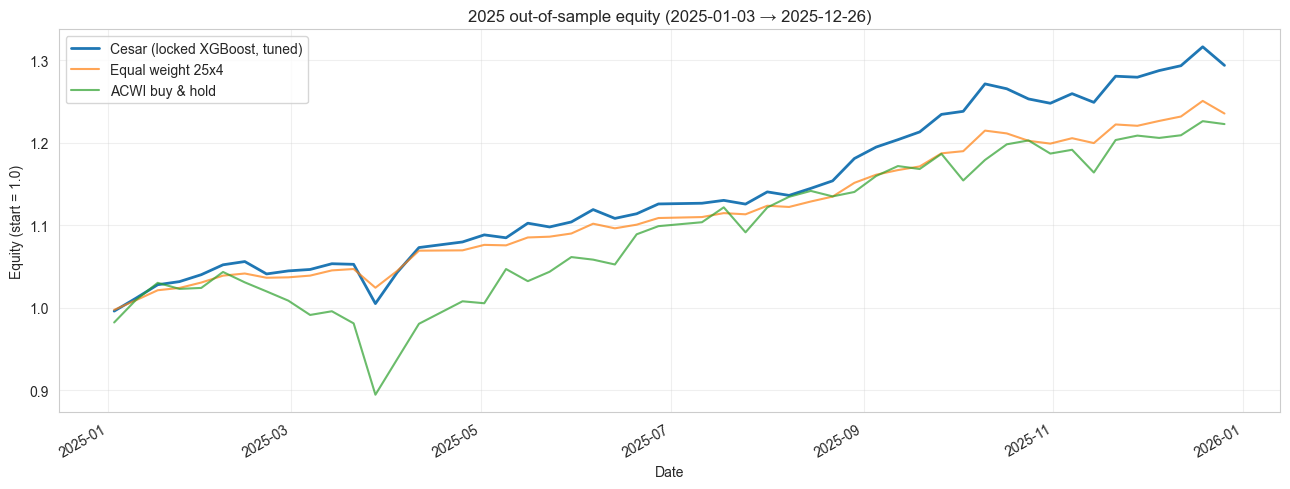

In [21]:
# 11.3) 2025 validation equity (tuned)
strat_25 = (1 + rets_2025).cumprod()
ew_25    = (1 + rets.reindex(idx_25).mul([0.25]*4).sum(axis=1)).cumprod()
acwi_25  = (1 + rets.reindex(idx_25)['ACWI']).cumprod()

fig, ax = plt.subplots(figsize=(13, 5))
strat_25.plot(ax=ax, label='Cesar (locked XGBoost, tuned)', lw=2)
ew_25.plot(ax=ax,    label='Equal weight 25x4', alpha=0.7)
acwi_25.plot(ax=ax,  label='ACWI buy & hold',   alpha=0.7)
ax.set_title(f'2025 out-of-sample equity ({idx_25.min().date()} → {idx_25.max().date()})')
ax.set_ylabel('Equity (start = 1.0)'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS / 'fig_8_3_validation_equity.png', dpi=120); plt.show()


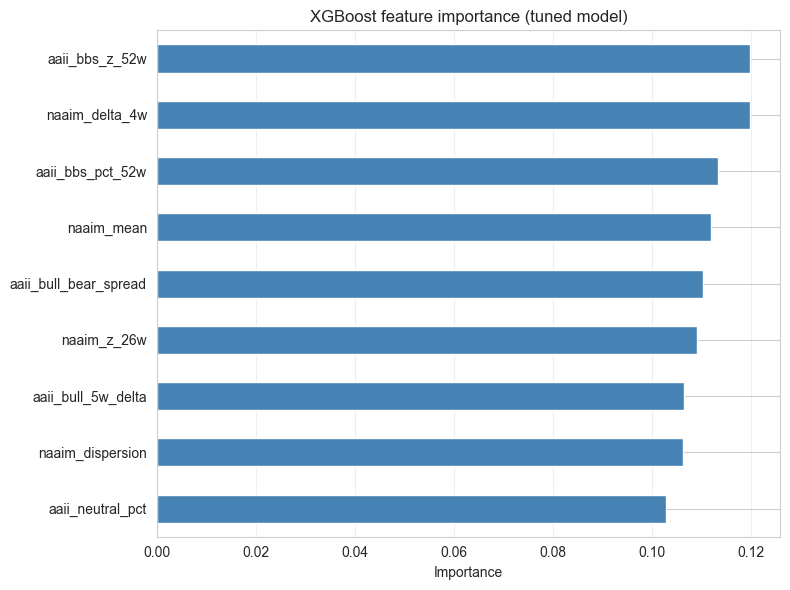

In [22]:
# 11.4) Feature importance
imp = pd.Series(final_model.feature_importances_, index=X_all.columns).sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
imp.plot.barh(ax=ax, color='steelblue')
ax.set_title('XGBoost feature importance (tuned model)')
ax.set_xlabel('Importance'); ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(RESULTS / 'fig_5_4_feature_importance.png', dpi=120); plt.show()


## 12) Live submission for next Friday

Use the locked tuned model on the freshest feature row to predict the **next** week's weights. Reads previous week from `submissions/cesar_history.csv` so re-runs are idempotent.

**Outputs:**
- `submissions/cesar_<next_friday>.csv` — one-row team submission
- `submissions/cesar_history.csv` — running history (append/overwrite by date)

In [23]:
def get_weights(as_of_date) -> pd.Series:
    """Canonical signal contract: Series indexed UNIVERSE, in [0,1], summing to 1."""
    target = pd.Timestamp(as_of_date)
    available = feats.loc[:target]
    if available.empty:
        raise ValueError(f"no features available on or before {target.date()}")
    latest = available.index.max()
    probs = final_model.predict_proba(available.loc[[latest], X_all.columns])[0]
    _frames = [oos_w, weights_2025 / 100.0]
    if not weights_ytd.empty:
        _frames.append(weights_ytd / 100.0)
    _hist = pd.concat(_frames).sort_index()
    _prior = _hist[_hist.index < target]
    w_prev = _prior.iloc[-1].values if len(_prior) > 0 else np.full(4, 0.25)
    pct = predict_weights(probs, w_prev, floor=FLOOR_TUNED, max_turnover=TURNOVER_CAP)
    return pd.Series(pct / 100.0, index=ETFS).reindex(UNIVERSE)


VERTICAL_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SUBMISSIONS_DIR = VERTICAL_ROOT / "submissions"
SUBMISSIONS_DIR.mkdir(exist_ok=True)
HIST = SUBMISSIONS_DIR / "cesar_history.csv"

latest_t = feats.index.max()
live_row = feats.loc[[latest_t], X_all.columns]
live_probs = final_model.predict_proba(live_row)[0]

if HIST.exists():
    prev_hist = pd.read_csv(HIST, index_col=0, parse_dates=True)
    w_prev_live = prev_hist.iloc[-1][ETFS].values / 100.0
else:
    prev_hist = None
    w_prev_live = oos_w.iloc[-1].values

w_live_pct = predict_weights(
    live_probs, w_prev_live, floor=FLOOR_TUNED, max_turnover=TURNOVER_CAP
)
next_friday = (latest_t + pd.Timedelta(days=7)).strftime("%Y-%m-%d")

assert abs(w_live_pct.sum() - 100) < 0.02
assert (w_live_pct >= 0).all()
turn_live = float(np.abs(w_live_pct / 100.0 - w_prev_live).sum()) * 100
assert turn_live <= TURNOVER_CAP * 100 + 0.02, f"Turnover {turn_live:.2f}pp exceeds cap"

print(f"Latest features as of {latest_t.date()}  ->  weights for {next_friday}:")
for t, w in zip(ETFS, w_live_pct):
    print(f"  {t}: {w:5.2f}%")
print(
    f"  Sum: {w_live_pct.sum():.2f}%   "
    f"Turnover vs prev: {turn_live:.2f}pp (cap {TURNOVER_CAP*100:.0f}pp)"
)

new_row = pd.DataFrame([w_live_pct], index=[pd.Timestamp(next_friday)], columns=ETFS)
full = pd.concat([prev_hist, new_row]) if prev_hist is not None else new_row
full = full[~full.index.duplicated(keep="last")].sort_index()
full.to_csv(HIST)

w_live_fraction = pd.Series(w_live_pct / 100.0, index=ETFS).reindex(UNIVERSE)
out_path = write_submission_csv(
    w_live_fraction,
    next_friday,
    TEAM_ID,
    SUBMISSIONS_DIR,
    vertical_tag="sentiment",
)
print(f"\nWrote {out_path}")
print(out_path.read_text())
print(f"Updated {HIST}")


Latest features as of 2026-05-29  ->  weights for 2026-06-05:
  ACWI: 32.51%
  AGG: 19.87%
  GLD: 29.07%
  BSV: 18.55%
  Sum: 100.00%   Turnover vs prev: 0.00pp (cap 25pp)

Wrote /Users/rayane/algo-trading-group/cesar-sentiment/submissions/TeamXX_sentiment_2026-06-05.csv
week,team_id,acwi,agg,gld,bsv
2026-06-05,TeamXX,32.51,19.87,29.07,18.55

Updated /Users/rayane/algo-trading-group/cesar-sentiment/submissions/cesar_history.csv


In [24]:
canonical_records = []
canonical_records.append({"segment": "TRAIN walk-forward OOS", "strategy": "XGBoost (Cesar)",
                          **compute_kpis(oos_rets)})
canonical_records.append({"segment": "VAL 2025", "strategy": "XGBoost (Cesar)",
                          **compute_kpis(rets_2025)})
if "rets_ytd" in dir() and len(rets_ytd) > 0:
    canonical_records.append({"segment": "2026 YTD", "strategy": "XGBoost (Cesar)",
                              **compute_kpis(rets_ytd)})

canonical_kpis_df = pd.DataFrame(canonical_records).set_index(["segment", "strategy"])

VERTICAL_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS_DIR_VR = VERTICAL_ROOT / "results"
RESULTS_DIR_VR.mkdir(exist_ok=True)
canonical_kpis_df.to_csv(RESULTS_DIR_VR / "kpis_segments.csv")

all_weights_history = pd.concat(
    [oos_w, weights_2025 / 100.0] + ([weights_ytd / 100.0] if "weights_ytd" in dir() and not weights_ytd.empty else [])
)
all_weights_history.to_csv(RESULTS_DIR_VR / "weekly_weights_history.csv")
print(f"Wrote {RESULTS_DIR_VR / 'kpis_segments.csv'}")
print(f"Wrote {RESULTS_DIR_VR / 'weekly_weights_history.csv'}")
canonical_kpis_df


Wrote /Users/rayane/algo-trading-group/cesar-sentiment/results/kpis_segments.csv
Wrote /Users/rayane/algo-trading-group/cesar-sentiment/results/weekly_weights_history.csv


,,n_periods,total_return,CAGR,ann_return,ann_vol,Sharpe,Sortino,max_drawdown,calmar,hit_rate,best_period,worst_period
segment,strategy,,,,,,,,,,,,
TRAIN walk-forward OOS,XGBoost (Cesar),758,1.6995,0.0705,0.0729,0.0970,0.7510,1.1293,-0.1803,0.3910,0.5475,0.0808,-0.0887
VAL 2025,XGBoost (Cesar),50,0.2936,0.3070,0.2729,0.0952,2.8659,4.9617,-0.0482,6.3651,0.7000,0.0376,-0.0452
2026 YTD,XGBoost (Cesar),20,0.0726,0.1999,0.1943,0.1575,NaN,NaN,-0.0837,2.3899,0.6000,0.0533,-0.0380
